PCA

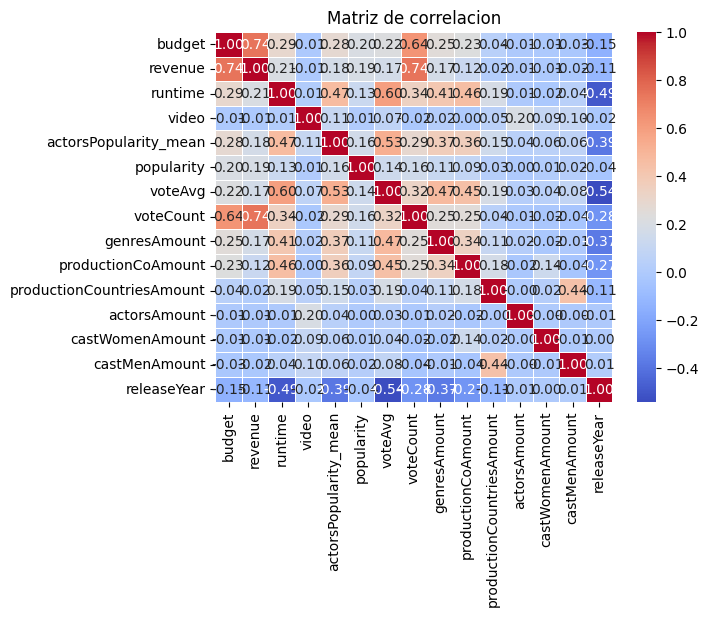

Chi-Square: 84913.71070016551, p-value: 0.000000
KMO: 0.8031266072388928


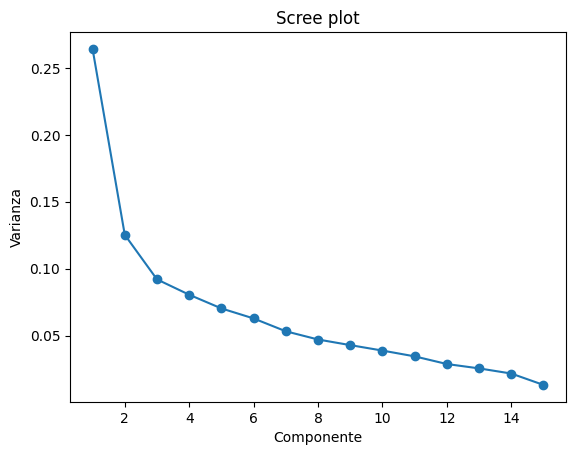

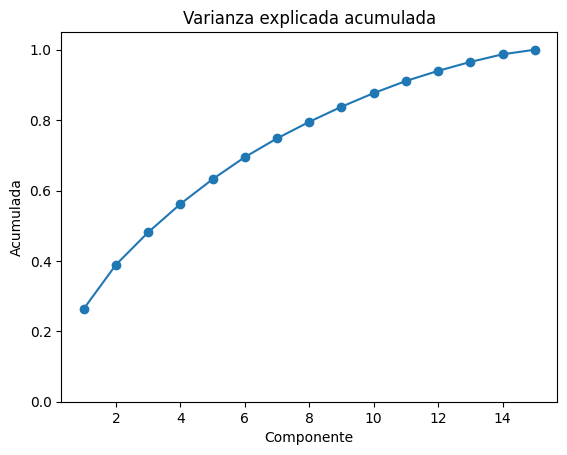

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo



df_movies_clean = pd.read_csv('movies_data_clean.csv', encoding='utf-8', encoding_errors='ignore')

X = df_movies_clean.select_dtypes(include=[np.number]).copy()

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

corr = X.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlacion")
plt.show()

chi_sq, p = calculate_bartlett_sphericity(X)
print(f'Chi-Square: {chi_sq}, p-value: {p:5f}')

kmo_all, kmo_model = calculate_kmo(Xz)
print(f"KMO: {kmo_model}")

pca = PCA()
X_pca = pca.fit_transform(Xz)

explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()

plt.plot(range(1, len(explained)+1), explained, marker="o")
plt.title("Scree plot")
plt.xlabel("Componente")
plt.ylabel("Varianza")
plt.show()

plt.plot(range(1, len(cum_explained)+1), cum_explained, marker="o")
plt.title("Varianza explicada acumulada")
plt.xlabel("Componente")
plt.ylabel("Acumulada")
plt.ylim(0, 1.05)
plt.show()
